# Polymarket BTC — 10 Estrategias Basadas en Reglas

Notebook sin ML. Todas las estrategias usan reglas duras (cruces de medias, umbrales, imbalances, etc.).

### Estrategias

| # | Nombre | Lógica |
|---|--------|--------|
| 1 | **Momentum BTC** | Si `btc_return_since_open > 0` → UP, else DOWN |
| 2 | **MA Crossover** | Si `ret_1m > ret_5m` → UP (short-term > long-term) |
| 3 | **Market Premium Follow** | Si `mkt_premium > 0` → UP (seguir al mercado) |
| 4 | **Divergence Reversion** | Si BTC sube pero mercado baja → comprar UP (mean reversion) |
| 5 | **Book Imbalance** | Si `up_book_imbalance > threshold` → UP |
| 6 | **Volume Spike + Momentum** | Alto volumen + retorno positivo → UP |
| 7 | **Low Vol Momentum** | Solo operar en baja volatilidad, seguir momentum |
| 8 | **Streak Contrarian** | Racha de UPs → apostar DOWN (reversión) |
| 9 | **Multi-Signal Consensus** | Voto mayoritario de señales |
| 10 | **Cheap Ask + Momentum** | Ask bajo (buen precio) + confirmación de dirección |

---
## 1 · Imports y Configuración

In [1]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# =============================================================================
# PARÁMETROS GLOBALES
# =============================================================================
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    TRAIN_FRAC   = 0.40,
    VAL_FRAC     = 0.15,

    STAKE        = 10.0,
    INIT_CAPITAL = 1_000.0,

    # Ventana de entrada (market_progress)
    ENTRY_LO     = 0.10,
    ENTRY_HI     = 0.60,

    # Mínimo value edge requerido (ask suficientemente barato)
    MIN_VE       = 0.0,  # por defecto 0 → sin filtro de VE
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<22} = {v}")

Configuración:
  DATA_PATH              = ../dataset_with_resolution.csv
  TRAIN_FRAC             = 0.4
  VAL_FRAC               = 0.15
  STAKE                  = 10.0
  INIT_CAPITAL           = 1000.0
  ENTRY_LO               = 0.1
  ENTRY_HI               = 0.6
  MIN_VE                 = 0.0


---
## 2 · Carga y Limpieza

In [2]:
# =============================================================================
# 2. CARGA Y LIMPIEZA
# =============================================================================
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')

df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

# Eliminar mercados con resolución inconsistente
res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
    print(f"Eliminados {len(bad)} mercados con resolución inconsistente.")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Mercados: {df['market_slug'].nunique():,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Resoluciones: {df['resolution'].value_counts().to_dict()}")

Dataset: 114,802 filas × 66 columnas
Mercados: 1,194
Rango: 2026-03-19 16:15:55.759706+00:00  →  2026-03-23 19:44:17.670852+00:00
Resoluciones: {'down': 57615, 'up': 57187}


In [3]:
# =============================================================================
# 2b. TIMING FEATURES
# =============================================================================
_times = (
    df.groupby('market_slug')['timestamp']
    .agg(market_open='min', market_close='max')
    .reset_index()
)
df = df.merge(_times, on='market_slug', how='left')

df['market_duration_s'] = (
    df['market_close'] - df['market_open']
).dt.total_seconds().clip(lower=1)

df['seconds_from_open'] = (
    df['timestamp'] - df['market_open']
).dt.total_seconds().clip(lower=0)

df['seconds_to_close'] = (
    df['market_close'] - df['timestamp']
).dt.total_seconds().clip(lower=0)

print(f"Timing features añadidos. Duración media: "
      f"{df['market_duration_s'].mean():.1f} s  "
      f"(mediana: {df['market_duration_s'].median():.1f} s)")

Timing features añadidos. Duración media: 296.7 s  (mediana: 296.8 s)


---
## 3 · Feature Engineering

In [4]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

fe['vol_ratio'] = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)
fe['mkt_premium'] = fe['up_ask_p_1'] - fe['down_ask_p_1']

fe['up_book_imbalance'] = (
    (fe['up_bid_s_1'] - fe['up_ask_s_1']) /
    (fe['up_bid_s_1'] + fe['up_ask_s_1'] + 1e-9)
)
fe['down_book_imbalance'] = (
    (fe['down_bid_s_1'] - fe['down_ask_s_1']) /
    (fe['down_bid_s_1'] + fe['down_ask_s_1'] + 1e-9)
)

fe['btc_poly_divergence'] = fe['btc_return_since_open'] - fe['mkt_premium']

# ── Rachas (sin look-ahead) ──────────────────────────────────────────────────
STREAK_WINDOW = 5

_res = (
    fe.groupby('market_slug').agg(
        resolution=('resolution', 'first'),
        close_ts=('market_close', 'first'),
        last_up_ask=('up_ask_p_1', 'last'),
    )
    .sort_values('close_ts')
    .reset_index()
)
_res['res_up'] = (_res['resolution'].str.lower() == 'up').astype(int)

_res['recent_up_pct_5'] = (
    _res['res_up'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

def compute_streak(series):
    shifted = series.shift(1)
    streaks = []
    for i in range(len(shifted)):
        if pd.isna(shifted.iloc[i]):
            streaks.append(0); continue
        streak = 0; last_val = shifted.iloc[i]
        for j in range(i, -1, -1):
            if pd.isna(shifted.iloc[j]) or shifted.iloc[j] != last_val: break
            streak += 1
        streaks.append(streak if last_val == 1 else -streak)
    return streaks

_res['recent_streak'] = compute_streak(_res['res_up'])

_res['was_surprise'] = (
    ((_res['res_up'] == 1) & (_res['last_up_ask'] < 0.50)) |
    ((_res['res_up'] == 0) & (_res['last_up_ask'] >= 0.50))
).astype(int)

_res['recent_mkt_surprise_5'] = (
    _res['was_surprise'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

_streak_map = _res.set_index('market_slug')[[
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5'
]]
fe = fe.merge(_streak_map, left_on='market_slug', right_index=True, how='left')
fe['recent_up_pct_5']       = fe['recent_up_pct_5'].fillna(0.5)
fe['recent_streak']         = fe['recent_streak'].fillna(0)
fe['recent_mkt_surprise_5'] = fe['recent_mkt_surprise_5'].fillna(0.5)

# ── Target ───────────────────────────────────────────────────────────────────
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

# ── Señales disponibles ───────────────────────────────────────────────────────
SIGNAL_COLS = [
    'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m', 'btc_return_since_open',
    'volatility_5m', 'vol_ratio', 'volume_1m',
    'mkt_premium', 'up_book_imbalance', 'down_book_imbalance',
    'btc_poly_divergence',
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5',
    'market_progress',
]
SIGNAL_COLS = [f for f in SIGNAL_COLS if f in fe.columns]
print(f"Señales disponibles: {len(SIGNAL_COLS)}")
print(fe[SIGNAL_COLS].describe().round(3).to_string())

Señales disponibles: 16
           ret_1m      ret_3m      ret_5m     ret_10m  btc_return_since_open  volatility_5m   vol_ratio   volume_1m  mkt_premium  up_book_imbalance  down_book_imbalance  btc_poly_divergence  recent_up_pct_5  recent_streak  recent_mkt_surprise_5  market_progress
count  114802.000  114802.000  114802.000  114802.000             114802.000     114801.000  114801.000  114801.000   106261.000         106262.000           106251.000           106261.000       114802.000     114802.000             114802.000       114802.000
mean        0.001       0.000       0.000       0.000                 -0.000          0.001       0.935      13.047        0.009             -0.007                0.006               -0.009            0.501         -0.010                  0.033            0.497
std         0.299       0.001       0.002       0.002                  0.001          0.000       0.351      28.428        0.524              0.621                0.621                0.524 

---
## 4 · Split Temporal por Mercado

In [5]:
# =============================================================================
# 4. SPLIT TEMPORAL POR MERCADO
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
val_m   = market_order[n_train : n_train + n_val]
test_m  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_m)].copy()
va = fe[fe['market_slug'].isin(val_m)].copy()
te = fe[fe['market_slug'].isin(test_m)].copy()

# Para backtest usamos val+test (out-of-sample)
oos = fe[fe['market_slug'].isin(val_m + test_m)].copy()

assert tr['timestamp'].max() < va['timestamp'].min(), "LEAKAGE train/val"
assert va['timestamp'].max() < te['timestamp'].min(), "LEAKAGE val/test"
print("Sin leakage temporal confirmado.")

print(f"\n{'Split':<12} {'Mercados':>9} {'Filas':>8} {'UP%':>6}")
print("-" * 38)
for name, split in [('Train', tr), ('Validación', va), ('Test', te), ('OOS total', oos)]:
    y_pct = (split['resolution'].str.lower() == 'up').mean()
    print(f"{name:<12} {split['market_slug'].nunique():>9,} {len(split):>8,} {y_pct:>6.1%}")

Sin leakage temporal confirmado.

Split         Mercados    Filas    UP%
--------------------------------------
Train              477   45,801  50.2%
Validación         179   17,228  50.6%
Test               538   51,773  49.2%
OOS total          717   69,001  49.5%


---
## 5 · Calibración de Umbrales (sobre Train)

Calculamos los percentiles de las señales clave sobre el set de entrenamiento
para definir los umbrales de cada estrategia de forma objetiva.

In [6]:
# =============================================================================
# 5. CALIBRACIÓN DE UMBRALES EN TRAIN
# =============================================================================
# Filtramos train a la ventana de operación para calibrar umbrales realistas
tr_window = tr[
    (tr['market_progress'] >= CFG['ENTRY_LO']) &
    (tr['market_progress'] <= CFG['ENTRY_HI'])
].copy()

print(f"Train en ventana de operación: {len(tr_window):,} snapshots")
print(f"\nPercentiles de señales clave (train, ventana operación):")
print("─" * 80)

key_signals = [
    'btc_return_since_open', 'ret_1m', 'ret_5m', 'mkt_premium',
    'btc_poly_divergence', 'up_book_imbalance', 'volatility_5m',
    'volume_1m', 'recent_streak', 'recent_up_pct_5',
]

for sig in key_signals:
    vals = tr_window[sig].dropna()
    pcts = vals.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    print(f"  {sig:<26} p10={pcts[0.10]:+.5f}  p25={pcts[0.25]:+.5f}  "
          f"p50={pcts[0.50]:+.5f}  p75={pcts[0.75]:+.5f}  p90={pcts[0.90]:+.5f}")

# Guardar medianas para uso en estrategias
TRAIN_MEDIANS = tr_window[key_signals].median().to_dict()
TRAIN_STDS    = tr_window[key_signals].std().to_dict()
VOL_P75       = tr_window['volatility_5m'].quantile(0.75)
VOL_P25       = tr_window['volatility_5m'].quantile(0.25)
VOLUME_P75    = tr_window['volume_1m'].quantile(0.75)

print(f"\nUmbrales derivados:")
print(f"  VOL_P25 = {VOL_P25:.6f}")
print(f"  VOL_P75 = {VOL_P75:.6f}")
print(f"  VOLUME_P75 = {VOLUME_P75:.2f}")

Train en ventana de operación: 23,215 snapshots

Percentiles de señales clave (train, ventana operación):
────────────────────────────────────────────────────────────────────────────────
  btc_return_since_open      p10=-0.00094  p25=-0.00044  p50=-0.00000  p75=+0.00040  p90=+0.00087
  ret_1m                     p10=-0.00074  p25=-0.00032  p50=-0.00000  p75=+0.00030  p90=+0.00065
  ret_5m                     p10=-0.00144  p25=-0.00070  p50=+0.00000  p75=+0.00073  p90=+0.00169
  mkt_premium                p10=-0.62000  p25=-0.35000  p50=+0.01000  p75=+0.31000  p90=+0.59000
  btc_poly_divergence        p10=-0.58965  p25=-0.30999  p50=-0.00950  p75=+0.34948  p90=+0.61954
  up_book_imbalance          p10=-0.85242  p25=-0.55188  p50=-0.04545  p75=+0.56082  p90=+0.85266
  volatility_5m              p10=+0.00020  p25=+0.00029  p50=+0.00045  p75=+0.00065  p90=+0.00096
  volume_1m                  p10=+2.01563  p25=+3.60445  p50=+7.24901  p75=+13.61474  p90=+25.86233
  recent_streak            

---
## 6 · Definición de las 10 Estrategias

In [7]:
# =============================================================================
# 6. DEFINICIÓN DE LAS 10 ESTRATEGIAS
# =============================================================================
#
# Cada estrategia es una función:
#   signal_fn(row) → 'UP', 'DOWN', o None (sin señal)
#
# La función recibe un snapshot (una fila del DataFrame) dentro de la
# ventana de operación y debe decidir dirección o abstenerse.
# =============================================================================


# ── 1. Momentum BTC ──────────────────────────────────────────────────────────
# Si BTC ha subido desde la apertura del mercado → UP, si ha bajado → DOWN
def strat_momentum(row):
    ret = row.get('btc_return_since_open', 0)
    if pd.isna(ret) or ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# ── 2. MA Crossover (ret_1m > ret_5m) ────────────────────────────────────────
# Short-term momentum supera al largo → señal alcista
def strat_ma_crossover(row):
    r1 = row.get('ret_1m', np.nan)
    r5 = row.get('ret_5m', np.nan)
    if pd.isna(r1) or pd.isna(r5):
        return None
    if r1 > r5:
        return 'UP'
    elif r1 < r5:
        return 'DOWN'
    return None


# ── 3. Market Premium Follow ──────────────────────────────────────────────────
# El mercado ya está "votando" una dirección → seguirlo
def strat_premium_follow(row):
    prem = row.get('mkt_premium', np.nan)
    if pd.isna(prem) or abs(prem) < 0.02:  # dead-zone
        return None
    return 'UP' if prem > 0 else 'DOWN'


# ── 4. Divergence Mean Reversion ──────────────────────────────────────────────
# BTC se ha movido pero el mercado no lo refleja → apostar a convergencia
# divergence = btc_return - mkt_premium
# Si divergence > threshold → el mercado no ha subido lo suficiente → UP
def strat_divergence(row):
    div = row.get('btc_poly_divergence', np.nan)
    if pd.isna(div):
        return None
    threshold = 0.002  # divergencia significativa
    if div > threshold:
        return 'UP'   # BTC subió más de lo que el mercado refleja
    elif div < -threshold:
        return 'DOWN' # BTC bajó más de lo que el mercado refleja
    return None


# ── 5. Book Imbalance ────────────────────────────────────────────────────────
# Desequilibrio en el libro de órdenes como indicador de presión
def strat_book_imbalance(row):
    up_imb   = row.get('up_book_imbalance', np.nan)
    down_imb = row.get('down_book_imbalance', np.nan)
    if pd.isna(up_imb) or pd.isna(down_imb):
        return None
    # Imbalance positivo = más bids que asks → presión compradora
    threshold = 0.15
    if up_imb > threshold and down_imb < -threshold:
        return 'UP'
    elif down_imb > threshold and up_imb < -threshold:
        return 'DOWN'
    return None


# ── 6. Volume Spike + Momentum ───────────────────────────────────────────────
# Alto volumen confirma la dirección del movimiento
def strat_volume_momentum(row):
    vol  = row.get('volume_1m', np.nan)
    ret  = row.get('ret_1m', np.nan)
    if pd.isna(vol) or pd.isna(ret):
        return None
    if vol < VOLUME_P75:  # solo operar con volumen alto
        return None
    if ret > 0:
        return 'UP'
    elif ret < 0:
        return 'DOWN'
    return None


# ── 7. Low Vol Momentum ──────────────────────────────────────────────────────
# En periodos de baja volatilidad, el momentum es más fiable
def strat_lowvol_momentum(row):
    vol5 = row.get('volatility_5m', np.nan)
    ret  = row.get('btc_return_since_open', np.nan)
    if pd.isna(vol5) or pd.isna(ret):
        return None
    if vol5 > VOL_P75:  # alta volatilidad → no operar
        return None
    if ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# ── 8. Streak Contrarian ─────────────────────────────────────────────────────
# Si hay racha larga de UPs → apostar DOWN (reversión a la media)
def strat_streak_contrarian(row):
    streak = row.get('recent_streak', np.nan)
    if pd.isna(streak):
        return None
    threshold = 3  # racha de al menos 3
    if streak >= threshold:
        return 'DOWN'  # revertir
    elif streak <= -threshold:
        return 'UP'    # revertir
    return None


# ── 9. Multi-Signal Consensus ────────────────────────────────────────────────
# Combina 5 señales simples, opera cuando ≥3 coinciden
def strat_consensus(row):
    votes_up = 0
    votes_down = 0
    
    # Señal 1: Momentum BTC
    ret = row.get('btc_return_since_open', 0)
    if not pd.isna(ret) and ret != 0:
        if ret > 0: votes_up += 1
        else: votes_down += 1
    
    # Señal 2: Market premium
    prem = row.get('mkt_premium', np.nan)
    if not pd.isna(prem) and abs(prem) > 0.01:
        if prem > 0: votes_up += 1
        else: votes_down += 1
    
    # Señal 3: ret_1m
    r1 = row.get('ret_1m', np.nan)
    if not pd.isna(r1) and r1 != 0:
        if r1 > 0: votes_up += 1
        else: votes_down += 1
    
    # Señal 4: ret_5m
    r5 = row.get('ret_5m', np.nan)
    if not pd.isna(r5) and r5 != 0:
        if r5 > 0: votes_up += 1
        else: votes_down += 1
    
    # Señal 5: Divergencia
    div = row.get('btc_poly_divergence', np.nan)
    if not pd.isna(div) and abs(div) > 0.001:
        if div > 0: votes_up += 1
        else: votes_down += 1
    
    min_votes = 3
    if votes_up >= min_votes:
        return 'UP'
    elif votes_down >= min_votes:
        return 'DOWN'
    return None


# ── 10. Cheap Ask + Momentum ─────────────────────────────────────────────────
# Solo comprar cuando el ask es barato (buen pago) Y el momentum confirma
def strat_cheap_momentum(row):
    ret  = row.get('btc_return_since_open', np.nan)
    up_ask   = row.get('up_ask_p_1', np.nan)
    down_ask = row.get('down_ask_p_1', np.nan)
    if pd.isna(ret) or pd.isna(up_ask) or pd.isna(down_ask):
        return None
    
    max_ask = 0.55  # solo comprar cuando el precio es "barato"
    
    if ret > 0 and up_ask <= max_ask:
        return 'UP'
    elif ret < 0 and down_ask <= max_ask:
        return 'DOWN'
    return None


# ── Registro de estrategias ───────────────────────────────────────────────────
STRATEGIES = [
    ('1_Momentum_BTC',       strat_momentum),
    ('2_MA_Crossover',       strat_ma_crossover),
    ('3_Premium_Follow',     strat_premium_follow),
    ('4_Divergence_Revert',  strat_divergence),
    ('5_Book_Imbalance',     strat_book_imbalance),
    ('6_Volume_Momentum',    strat_volume_momentum),
    ('7_LowVol_Momentum',   strat_lowvol_momentum),
    ('8_Streak_Contrarian',  strat_streak_contrarian),
    ('9_Consensus',          strat_consensus),
    ('10_Cheap_Momentum',    strat_cheap_momentum),
]

print(f"Estrategias definidas: {len(STRATEGIES)}")
for name, _ in STRATEGIES:
    print(f"  • {name}")

Estrategias definidas: 10
  • 1_Momentum_BTC
  • 2_MA_Crossover
  • 3_Premium_Follow
  • 4_Divergence_Revert
  • 5_Book_Imbalance
  • 6_Volume_Momentum
  • 7_LowVol_Momentum
  • 8_Streak_Contrarian
  • 9_Consensus
  • 10_Cheap_Momentum


---
## 7 · Motor de Backtest (Rule-Based)

In [8]:
# =============================================================================
# 7. MOTOR DE BACKTEST — RULE-BASED
# =============================================================================


def find_entry_rule(market_snaps, cfg, signal_fn):
    """
    Punto de entrada para UN mercado con regla dura.
    Recorre snapshots en ventana ENTRY_LO–ENTRY_HI.
    Devuelve el primer snapshot donde signal_fn da señal.
    """
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']
    window = (
        market_snaps[
            (market_snaps['market_progress'] >= lo) &
            (market_snaps['market_progress'] <= hi)
        ]
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    if window.empty:
        return None, None

    for _, row in window.iterrows():
        direction = signal_fn(row)
        if direction is None:
            continue

        # Verificar que el ask es válido
        ask_col = 'up_ask_p_1' if direction == 'UP' else 'down_ask_p_1'
        ask = float(row[ask_col])
        if pd.isna(ask) or ask <= 0 or ask >= 1.0:
            continue

        return row, direction

    return None, None


def run_backtest_rule(snapshot_df, cfg, signal_fn):
    """
    Backtest para estrategia rule-based.
    - UN trade por mercado
    - Hold hasta resolución (sin exit anticipado, no hay modelo)
    """
    STAKE = cfg['STAKE']
    trades = []

    for mkt, grp in snapshot_df.groupby('market_slug'):
        snaps = grp.sort_values('timestamp').reset_index(drop=True)

        entry_row, direction = find_entry_rule(snaps, cfg, signal_fn)
        if entry_row is None:
            continue

        entry_ts = entry_row['timestamp']
        entry_ask = (
            entry_row['up_ask_p_1'] if direction == 'UP'
            else entry_row['down_ask_p_1']
        )
        if entry_ask <= 0 or np.isnan(entry_ask):
            continue

        resolution = snaps['resolution'].iloc[0]
        actual_up  = (resolution.lower() == 'up')
        won = (actual_up if direction == 'UP' else not actual_up)
        win_net  = entry_row['up_win_net']  if direction == 'UP' else entry_row['down_win_net']
        loss_net = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl = win_net if won else loss_net

        trades.append({
            'timestamp'        : entry_ts,
            'market'           : mkt,
            'direction'        : direction,
            'resolution'       : resolution,
            'won'              : won,
            'entry_progress'   : entry_row['market_progress'],
            'entry_ask'        : entry_ask,
            'pnl'              : pnl,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity'] = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


def compute_stats(tdf, equity_s, cfg):
    """Calcula métricas de una estrategia."""
    if tdf.empty:
        return dict(n=0, wr=np.nan, pnl=0, roi=0, pf=0, mdd=0, sharpe=0,
                    avg_pnl=0, max_win=0, max_loss=0)
    
    n  = len(tdf)
    nw = (tdf['pnl'] > 0).sum()
    wr = nw / n
    gp = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gl = tdf[tdf['pnl'] < 0]['pnl'].abs().sum()
    pf = gp / (gl + 1e-9)
    total = tdf['pnl'].sum()
    roi = total / cfg['INIT_CAPITAL']
    
    eq = equity_s.values
    rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()
    
    pa = tdf['pnl'].values
    sharpe = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)
    
    return dict(
        n=n, wr=wr, pnl=total, roi=roi, pf=pf, mdd=mdd, sharpe=sharpe,
        avg_pnl=pa.mean(), max_win=pa.max(), max_loss=pa.min(),
    )


print("Motor de backtest rule-based definido.")

Motor de backtest rule-based definido.


---
## 8 · Backtest de las 10 Estrategias (Out-of-Sample)

In [9]:
# =============================================================================
# 8. BACKTEST — TODAS LAS ESTRATEGIAS (sobre test set)
# =============================================================================
test_fe = te.copy()

results = {}
trade_logs = {}
equity_curves = {}

print(f"Ejecutando backtest sobre TEST ({test_fe['market_slug'].nunique()} mercados)...")
print(f"\n{'#':<4} {'Estrategia':<25} {'N':>5} {'WR':>7} {'PnL':>10} {'ROI':>8} "
      f"{'PF':>7} {'MDD':>8} {'Sharpe':>8}")
print("═" * 90)

for name, signal_fn in STRATEGIES:
    tdf, eq_s = run_backtest_rule(test_fe, CFG, signal_fn)
    stats = compute_stats(tdf, eq_s, CFG)
    
    results[name] = stats
    trade_logs[name] = tdf
    equity_curves[name] = eq_s
    
    s = stats
    wr_str  = f"{s['wr']:.1%}" if not np.isnan(s['wr']) else 'n/a'
    print(f"{name.split('_')[0]:<4} {name:<25} {s['n']:>5} {wr_str:>7} "
          f"{s['pnl']:>+10.2f} {s['roi']:>+7.2%} {s['pf']:>7.2f} "
          f"{s['mdd']:>+7.2%} {s['sharpe']:>8.3f}")

print("═" * 90)

# Baseline: random (50/50)
print(f"\n{'':>4} {'BASELINE_Random':<25} ", end="")
print(f"(esperado: WR≈50%, ROI≈-fee, Sharpe≈0)")

Ejecutando backtest sobre TEST (538 mercados)...

#    Estrategia                    N      WR        PnL      ROI      PF      MDD   Sharpe
══════════════════════════════════════════════════════════════════════════════════════════
1    1_Momentum_BTC              538   60.6%     -28.49  -2.85%    0.99 -18.86%   -0.149
2    2_MA_Crossover              538   50.6%     -13.40  -1.34%    0.99 -30.93%   -0.052
3    3_Premium_Follow            538   62.1%     +22.28  +2.23%    1.01 -16.91%    0.120
4    4_Divergence_Revert         538   38.7%     -80.31  -8.03%    0.98 -26.76%   -0.264
5    5_Book_Imbalance            538   49.1%    -168.88 -16.89%    0.94 -27.90%   -0.665
6    6_Volume_Momentum           273   62.6%    +181.21 +18.12%    1.18 -13.00%    1.141
7    7_LowVol_Momentum           417   62.4%     +66.13  +6.61%    1.04 -11.10%    0.398
8    8_Streak_Contrarian         121   57.9%    +178.14 +17.81%    1.35  -6.36%    1.484
9    9_Consensus                 538   52.0%    -207.74 

---
## 9 · Ranking y Comparativa

In [10]:
# =============================================================================
# 9. RANKING
# =============================================================================
ranking = pd.DataFrame(results).T
ranking = ranking.sort_values('pnl', ascending=False)

print("RANKING POR PnL TOTAL (Test Set)")
print("═" * 95)
print(f"{'Rank':>4} {'Estrategia':<25} {'N':>5} {'WR':>7} {'PnL':>10} {'ROI':>8} "
      f"{'PF':>7} {'MDD':>8} {'Sharpe':>8} {'Avg/Trade':>10}")
print("─" * 95)

for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    flag = ' ★' if row['pnl'] > 0 and row['sharpe'] > 0 else ''
    wr_str = f"{row['wr']:.1%}" if not np.isnan(row['wr']) else 'n/a'
    print(f"{rank:>4} {name:<25} {int(row['n']):>5} {wr_str:>7} "
          f"{row['pnl']:>+10.2f} {row['roi']:>+7.2%} {row['pf']:>7.2f} "
          f"{row['mdd']:>+7.2%} {row['sharpe']:>8.3f} {row['avg_pnl']:>+10.4f}{flag}")

print("\n★ = PnL > 0 y Sharpe > 0 (candidatas a producción)")

# Resumen rápido
profitable = ranking[ranking['pnl'] > 0]
print(f"\nEstrategias rentables: {len(profitable)}/{len(ranking)}")
if len(profitable):
    print(f"Mejor PnL:    {profitable.index[0]} ({profitable['pnl'].iloc[0]:+.2f} USDC)")
    best_sharpe = ranking.loc[ranking['sharpe'].idxmax()]
    print(f"Mejor Sharpe: {ranking['sharpe'].idxmax()} ({best_sharpe['sharpe']:.3f})")

RANKING POR PnL TOTAL (Test Set)
═══════════════════════════════════════════════════════════════════════════════════════════════
Rank Estrategia                    N      WR        PnL      ROI      PF      MDD   Sharpe  Avg/Trade
───────────────────────────────────────────────────────────────────────────────────────────────
   1 6_Volume_Momentum           273   62.6%    +181.21 +18.12%    1.18 -13.00%    1.141    +0.6638 ★
   2 8_Streak_Contrarian         121   57.9%    +178.14 +17.81%    1.35  -6.36%    1.484    +1.4722 ★
   3 10_Cheap_Momentum           422   52.4%    +120.99 +12.10%    1.06 -16.14%    0.593    +0.2867 ★
   4 7_LowVol_Momentum           417   62.4%     +66.13  +6.61%    1.04 -11.10%    0.398    +0.1586 ★
   5 3_Premium_Follow            538   62.1%     +22.28  +2.23%    1.01 -16.91%    0.120    +0.0414 ★
   6 2_MA_Crossover              538   50.6%     -13.40  -1.34%    0.99 -30.93%   -0.052    -0.0249
   7 1_Momentum_BTC              538   60.6%     -28.49  -2.85%

---
## 10 · Curvas de Equity

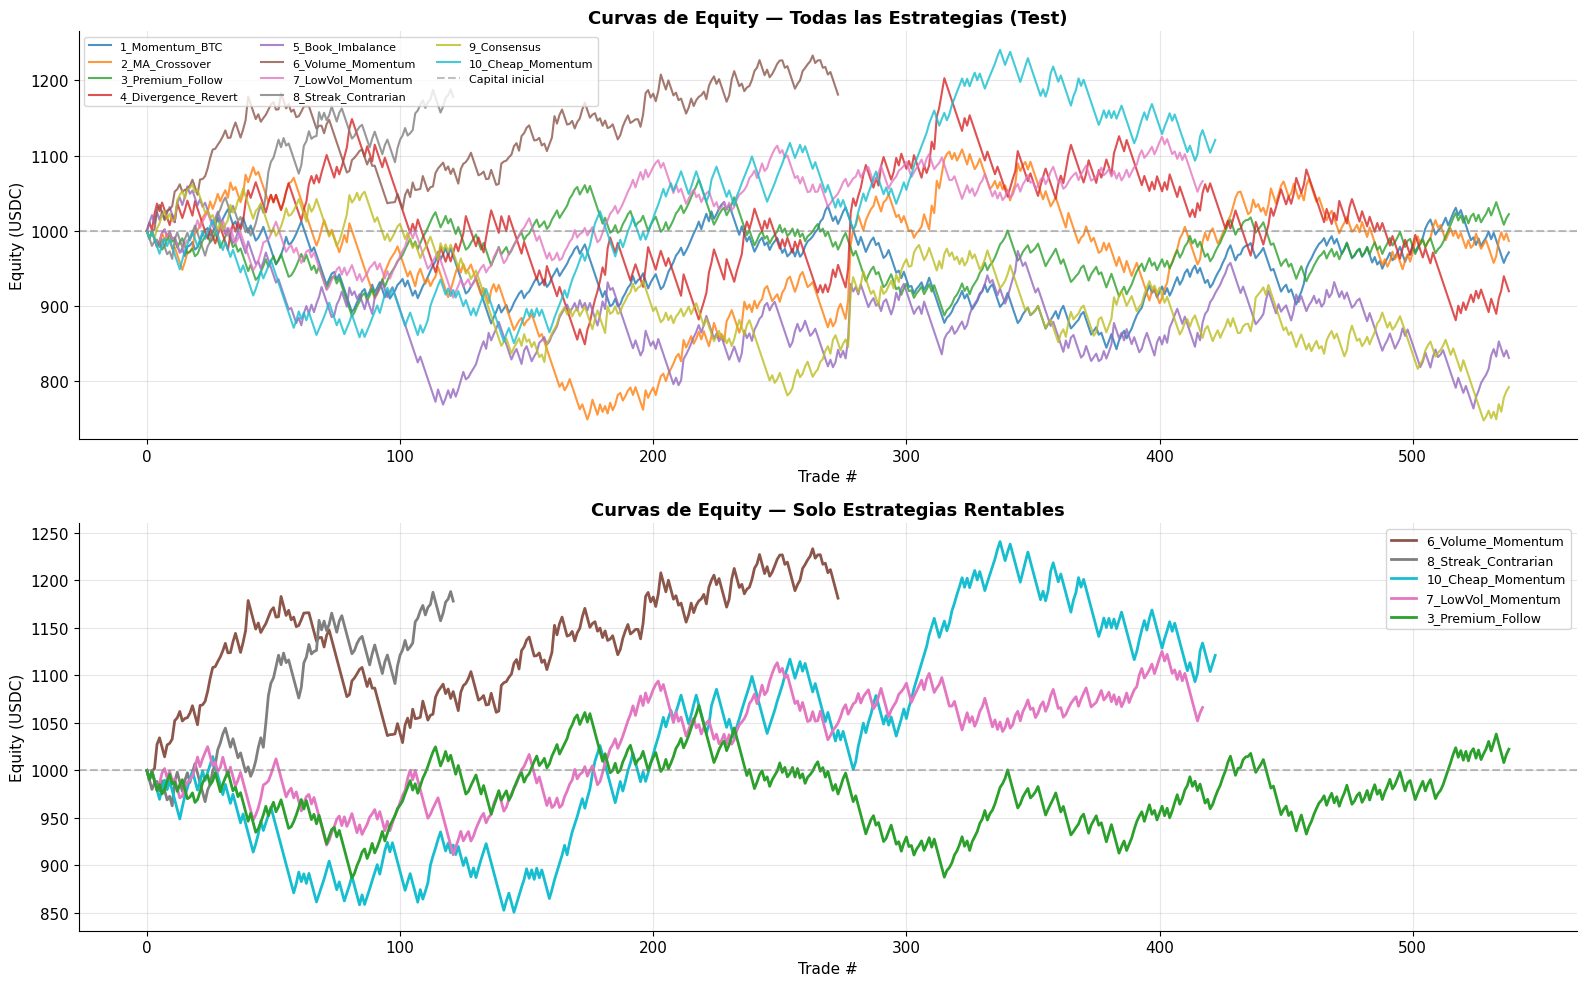

In [11]:
# =============================================================================
# 10. GRÁFICOS — CURVAS DE EQUITY
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Paleta de colores
colors = plt.cm.tab10(np.linspace(0, 1, len(STRATEGIES)))

# Panel 1: Todas las estrategias
ax = axes[0]
for i, (name, _) in enumerate(STRATEGIES):
    eq = equity_curves[name]
    if len(eq) > 1:
        ax.plot(range(len(eq)), eq.values, label=name, color=colors[i], lw=1.5, alpha=0.8)

ax.axhline(CFG['INIT_CAPITAL'], ls='--', color='gray', alpha=0.5, label='Capital inicial')
ax.set_title('Curvas de Equity — Todas las Estrategias (Test)', fontweight='bold', fontsize=13)
ax.set_ylabel('Equity (USDC)')
ax.set_xlabel('Trade #')
ax.legend(fontsize=8, ncol=3, loc='upper left')

# Panel 2: Solo las rentables
ax = axes[1]
profitable_names = ranking[ranking['pnl'] > 0].index.tolist()
if profitable_names:
    for name in profitable_names:
        eq = equity_curves[name]
        if len(eq) > 1:
            idx = [n for n, _ in STRATEGIES].index(name)
            ax.plot(range(len(eq)), eq.values, label=name, color=colors[idx], lw=2)
    ax.axhline(CFG['INIT_CAPITAL'], ls='--', color='gray', alpha=0.5)
    ax.set_title('Curvas de Equity — Solo Estrategias Rentables', fontweight='bold', fontsize=13)
    ax.set_ylabel('Equity (USDC)')
    ax.set_xlabel('Trade #')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Ninguna estrategia fue rentable en test',
            ha='center', va='center', fontsize=14, color='red', transform=ax.transAxes)

plt.tight_layout()
plt.show()

---
## 11 · Análisis de Win Rate por Dirección

In [12]:
# =============================================================================
# 11. ANÁLISIS POR DIRECCIÓN (UP vs DOWN)
# =============================================================================
print(f"{'Estrategia':<25} {'N_UP':>5} {'WR_UP':>7} {'N_DN':>5} {'WR_DN':>7} "
      f"{'PnL_UP':>10} {'PnL_DN':>10}")
print("─" * 80)

for name, _ in STRATEGIES:
    tdf = trade_logs[name]
    if tdf.empty:
        print(f"{name:<25}   sin trades")
        continue
    
    up_trades   = tdf[tdf['direction'] == 'UP']
    down_trades = tdf[tdf['direction'] == 'DOWN']
    
    n_up = len(up_trades)
    n_dn = len(down_trades)
    wr_up = up_trades['won'].mean() if n_up > 0 else np.nan
    wr_dn = down_trades['won'].mean() if n_dn > 0 else np.nan
    pnl_up = up_trades['pnl'].sum() if n_up > 0 else 0
    pnl_dn = down_trades['pnl'].sum() if n_dn > 0 else 0
    
    wr_up_s = f"{wr_up:.1%}" if not np.isnan(wr_up) else 'n/a'
    wr_dn_s = f"{wr_dn:.1%}" if not np.isnan(wr_dn) else 'n/a'
    
    print(f"{name:<25} {n_up:>5} {wr_up_s:>7} {n_dn:>5} {wr_dn_s:>7} "
          f"{pnl_up:>+10.2f} {pnl_dn:>+10.2f}")

Estrategia                 N_UP   WR_UP  N_DN   WR_DN     PnL_UP     PnL_DN
────────────────────────────────────────────────────────────────────────────────
1_Momentum_BTC              272   59.9%   266   61.3%     -69.09     +40.60
2_MA_Crossover              256   50.0%   282   51.1%      -0.05     -13.35
3_Premium_Follow            276   61.2%   262   63.0%     -34.07     +56.35
4_Divergence_Revert         262   37.8%   276   39.5%     -84.99      +4.68
5_Book_Imbalance            294   48.6%   244   49.6%    -113.62     -55.26
6_Volume_Momentum           141   63.8%   132   61.4%    +100.87     +80.34
7_LowVol_Momentum           205   62.9%   212   61.8%     +26.02     +40.11
8_Streak_Contrarian          63   55.6%    58   60.3%     +85.77     +92.37
9_Consensus                 256   51.6%   282   52.5%    -157.71     -50.02
10_Cheap_Momentum           198   49.5%   224   54.9%     -41.44    +162.43


---
## 12 · Distribución de PnL por Estrategia

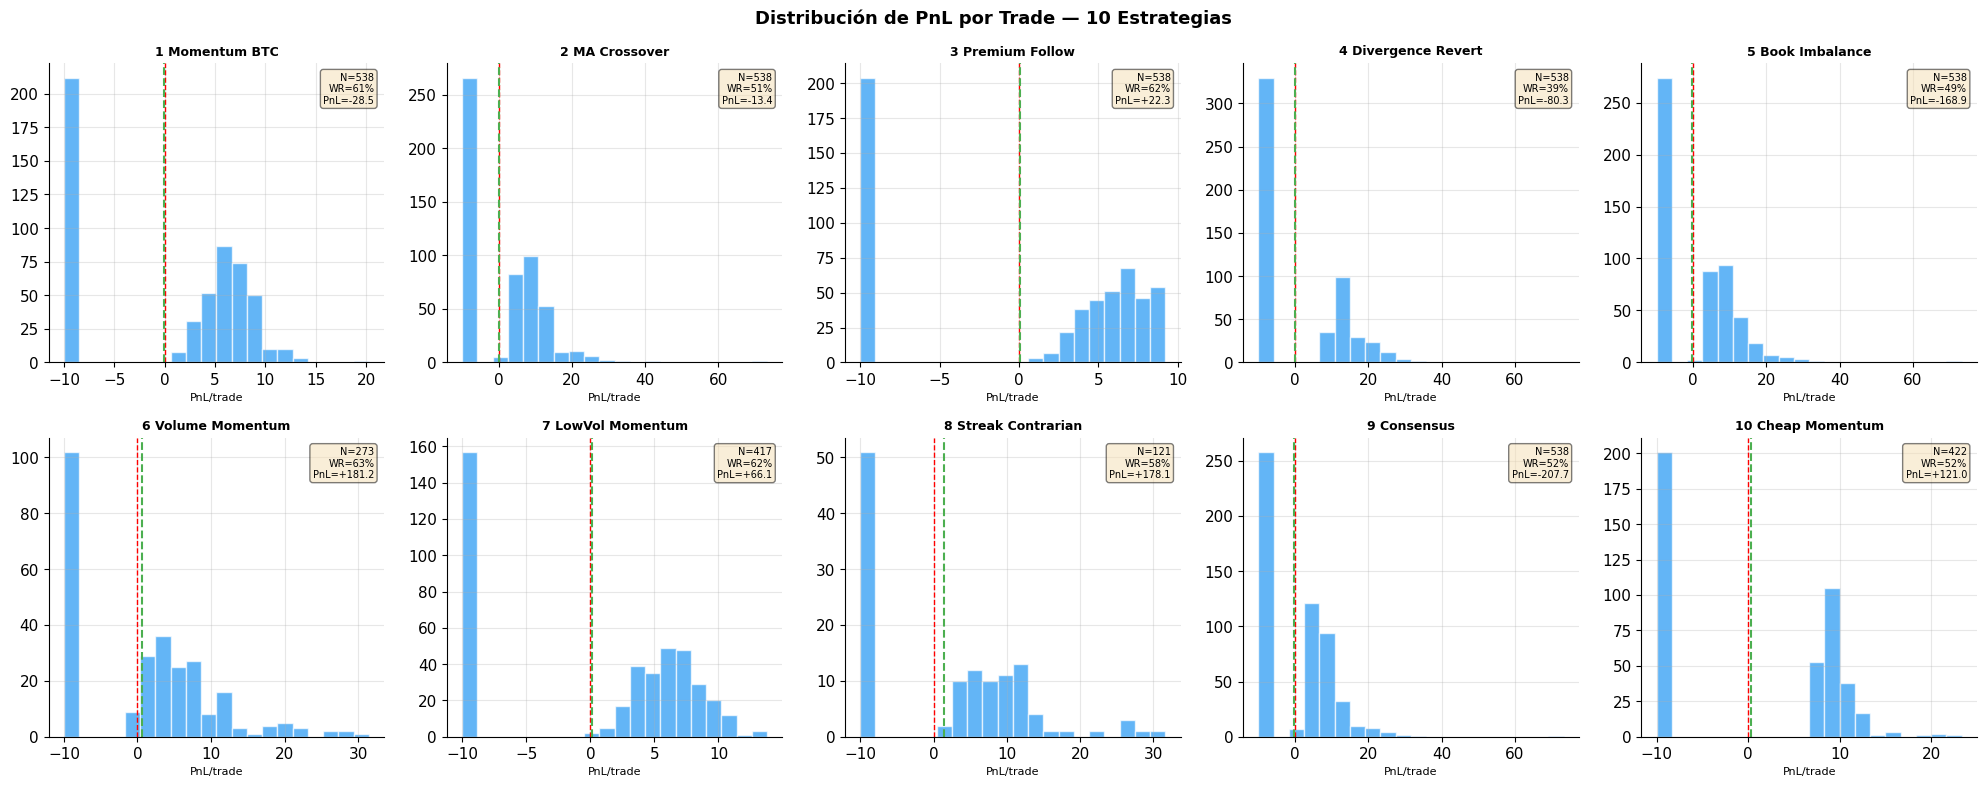

In [13]:
# =============================================================================
# 12. DISTRIBUCIÓN DE PnL
# =============================================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (name, _) in enumerate(STRATEGIES):
    ax = axes[i]
    tdf = trade_logs[name]
    if tdf.empty:
        ax.text(0.5, 0.5, 'Sin trades', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name.replace('_', ' '), fontsize=9, fontweight='bold')
        continue
    
    pnl_vals = tdf['pnl'].values
    colors_h = ['#4CAF50' if v > 0 else '#F44336' for v in pnl_vals]
    
    ax.hist(pnl_vals, bins=20, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(pnl_vals.mean(), ls='--', color='#4CAF50', lw=1.5)
    ax.set_title(name.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('PnL/trade', fontsize=8)
    
    stats = results[name]
    ax.text(0.97, 0.97, f"N={stats['n']}\nWR={stats['wr']:.0%}\nPnL={stats['pnl']:+.1f}",
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribución de PnL por Trade — 10 Estrategias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13 · Heatmap de Métricas

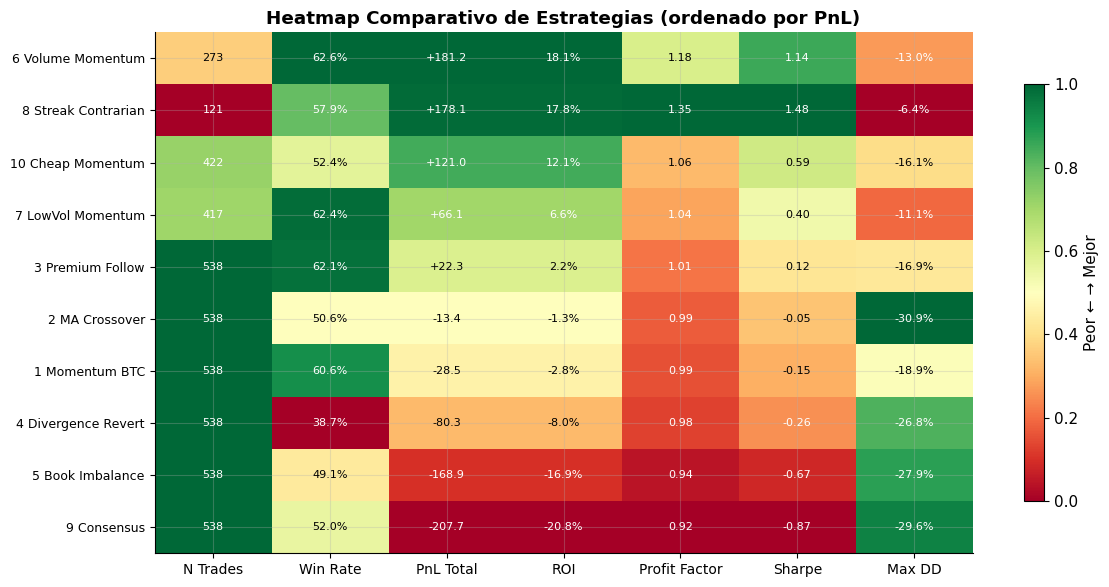

In [14]:
# =============================================================================
# 13. HEATMAP COMPARATIVO
# =============================================================================
metrics_display = ranking[['n', 'wr', 'pnl', 'roi', 'pf', 'sharpe', 'mdd']].copy()
metrics_display.columns = ['N Trades', 'Win Rate', 'PnL Total', 'ROI', 
                            'Profit Factor', 'Sharpe', 'Max DD']

fig, ax = plt.subplots(figsize=(12, 6))

# Normalizar para el heatmap
norm_df = metrics_display.copy()
for col in norm_df.columns:
    rng = norm_df[col].max() - norm_df[col].min()
    if rng > 0:
        norm_df[col] = (norm_df[col] - norm_df[col].min()) / rng
    else:
        norm_df[col] = 0.5

# Para MDD, invertir (menos negativo = mejor)
norm_df['Max DD'] = 1 - norm_df['Max DD']

im = ax.imshow(norm_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(metrics_display.columns)))
ax.set_xticklabels(metrics_display.columns, fontsize=10)
ax.set_yticks(range(len(metrics_display)))
ax.set_yticklabels([n.replace('_', ' ') for n in metrics_display.index], fontsize=9)

# Escribir valores reales en cada celda
for i in range(len(metrics_display)):
    for j in range(len(metrics_display.columns)):
        val = metrics_display.iloc[i, j]
        col_name = metrics_display.columns[j]
        if col_name in ['Win Rate', 'ROI', 'Max DD']:
            txt = f"{val:.1%}"
        elif col_name in ['PnL Total']:
            txt = f"{val:+.1f}"
        elif col_name in ['Sharpe', 'Profit Factor']:
            txt = f"{val:.2f}"
        else:
            txt = f"{val:.0f}"
        ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                color='black' if 0.3 < norm_df.iloc[i, j] < 0.7 else 'white')

ax.set_title('Heatmap Comparativo de Estrategias (ordenado por PnL)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Peor ← → Mejor', shrink=0.8)
plt.tight_layout()
plt.show()

---
## 14 · Validación Monte Carlo (Top 3 Estrategias)

Para las 3 mejores estrategias por PnL, ejecutamos Monte Carlo
con splits aleatorios de mercados completos.

In [15]:
# =============================================================================
# 14. MONTE CARLO — TOP 3 ESTRATEGIAS
# =============================================================================
N_MC_ITERS = 30
TEST_PCT   = 0.45  # % mercados para test en cada iter
rng = np.random.RandomState(SEED)

# Seleccionar top 3 por PnL
top3 = ranking.head(3).index.tolist()
top3_fns = {name: fn for name, fn in STRATEGIES if name in top3}

all_markets = fe['market_slug'].unique().tolist()
N_mkts = len(all_markets)
n_test = int(N_mkts * TEST_PCT)

print(f"Monte Carlo: {N_MC_ITERS} iteraciones")
print(f"Mercados: {N_mkts} total → {n_test} test por iteración")
print(f"\nEstrategias evaluadas: {top3}")

mc_all = {name: [] for name in top3}

for it in range(N_MC_ITERS):
    shuffled = rng.permutation(all_markets)
    mc_test_m = shuffled[:n_test].tolist()
    mc_test_df = fe[fe['market_slug'].isin(mc_test_m)].copy()
    
    for name in top3:
        signal_fn = top3_fns[name]
        tdf, eq_s = run_backtest_rule(mc_test_df, CFG, signal_fn)
        stats = compute_stats(tdf, eq_s, CFG)
        mc_all[name].append(stats)

# Imprimir resultados
print(f"\n{'═' * 80}")
print(f"  MONTE CARLO — RESUMEN ({N_MC_ITERS} iteraciones)")
print(f"{'═' * 80}")

mc_summary = {}
for name in top3:
    mc_df = pd.DataFrame(mc_all[name])
    mc_valid = mc_df[mc_df['n'] > 0]
    mc_summary[name] = mc_valid
    
    print(f"\n  ── {name} ──")
    if len(mc_valid) == 0:
        print("    Sin trades en ninguna iteración.")
        continue
    
    for col, label, fmt in [
        ('n',      'N trades',      '.1f'),
        ('wr',     'Win Rate',      '.1%'),
        ('pnl',    'PnL (USDC)',    '+.2f'),
        ('roi',    'ROI',           '+.2%'),
        ('pf',     'Profit Factor', '.2f'),
        ('mdd',    'Max Drawdown',  '.2%'),
        ('sharpe', 'Sharpe',        '.2f'),
    ]:
        v = mc_valid[col].dropna()
        print(f"    {label:<16} media={v.mean():{fmt}}  med={v.median():{fmt}}  "
              f"std={v.std():{fmt}}")
    
    pct_profit = (mc_valid['pnl'] > 0).mean()
    print(f"    Iteraciones rentables: {pct_profit:.0%} ({(mc_valid['pnl']>0).sum()}/{len(mc_valid)})")

Monte Carlo: 30 iteraciones
Mercados: 1194 total → 537 test por iteración

Estrategias evaluadas: ['6_Volume_Momentum', '8_Streak_Contrarian', '10_Cheap_Momentum']

════════════════════════════════════════════════════════════════════════════════
  MONTE CARLO — RESUMEN (30 iteraciones)
════════════════════════════════════════════════════════════════════════════════

  ── 6_Volume_Momentum ──
    N trades         media=246.0  med=245.5  std=10.6
    Win Rate         media=56.9%  med=57.2%  std=2.4%
    PnL (USDC)       media=-70.48  med=-62.86  std=+119.20
    ROI              media=-7.05%  med=-6.29%  std=+11.92%
    Profit Factor    media=0.94  med=0.94  std=0.11
    Max Drawdown     media=-19.67%  med=-18.38%  std=6.72%
    Sharpe           media=-0.48  med=-0.43  std=0.79
    Iteraciones rentables: 30% (9/30)

  ── 8_Streak_Contrarian ──
    N trades         media=127.7  med=127.0  std=6.7
    Win Rate         media=56.7%  med=56.5%  std=3.6%
    PnL (USDC)       media=+112.08  med=

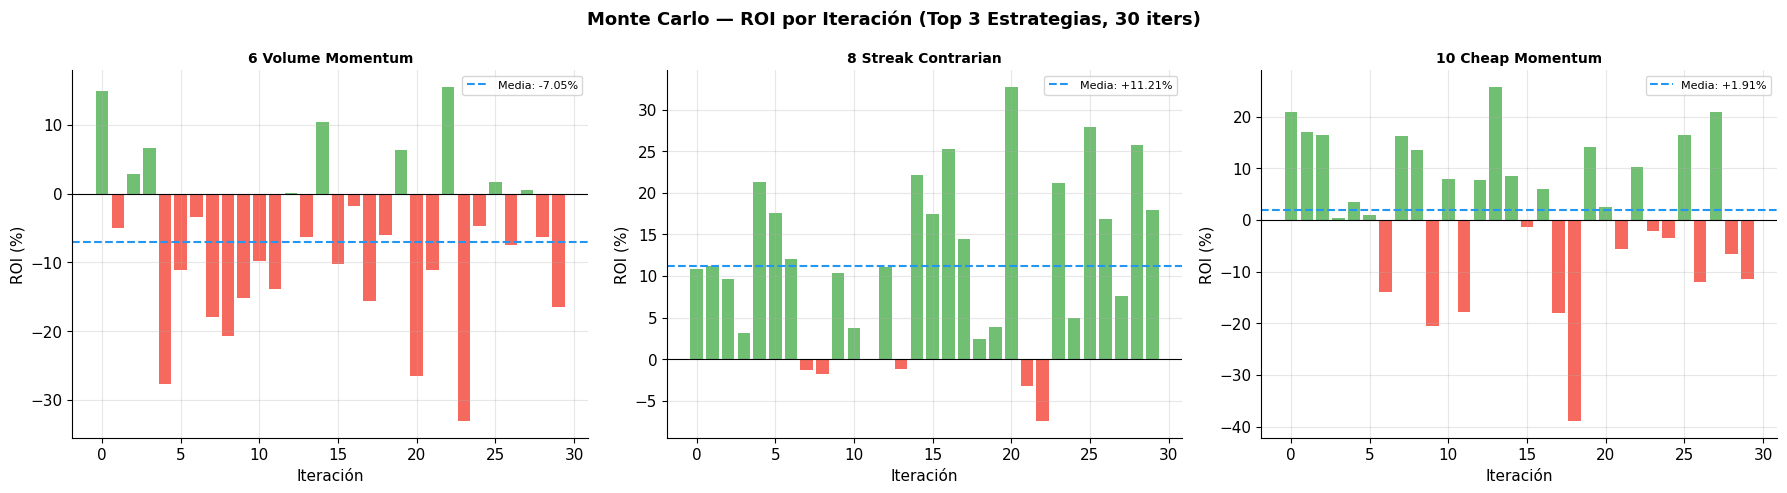

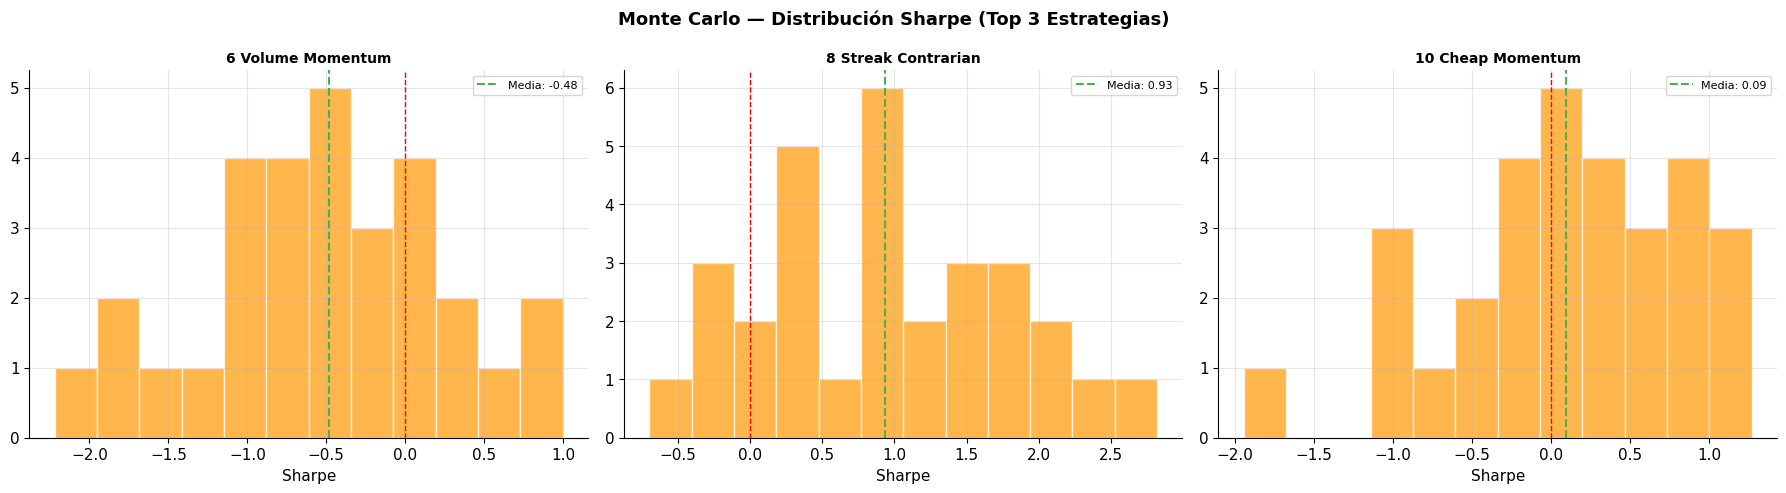

In [16]:
# =============================================================================
# 14b. GRÁFICOS MONTE CARLO
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(top3):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty or len(mc_v) < 2:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
        continue
    
    c_roi = ['#4CAF50' if v > 0 else '#F44336' for v in mc_v['roi']]
    ax.bar(range(len(mc_v)), mc_v['roi'].values * 100, color=c_roi, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(mc_v['roi'].mean() * 100, ls='--', color='#2196F3', lw=1.5,
               label=f"Media: {mc_v['roi'].mean():+.2%}")
    ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_ylabel('ROI (%)')
    ax.set_xlabel('Iteración')
    ax.legend(fontsize=8)

plt.suptitle(f'Monte Carlo — ROI por Iteración (Top 3 Estrategias, {N_MC_ITERS} iters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribución de Sharpe
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(top3):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty or len(mc_v) < 2:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
        continue
    
    ax.hist(mc_v['sharpe'], bins=12, color='#FF9800', alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(mc_v['sharpe'].mean(), ls='--', color='#4CAF50', lw=1.5,
               label=f"Media: {mc_v['sharpe'].mean():.2f}")
    ax.set_title(name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8)

plt.suptitle(f'Monte Carlo — Distribución Sharpe (Top 3 Estrategias)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 15 · Análisis de Sensibilidad (Entry Window)

In [17]:
# =============================================================================
# 15. SENSIBILIDAD — VENTANA DE ENTRADA
# =============================================================================
# Probamos distintas ventanas de entrada para la mejor estrategia

best_strat_name = ranking.index[0]
best_strat_fn = dict(STRATEGIES)[best_strat_name]

windows = [
    (0.05, 0.30),
    (0.10, 0.40),
    (0.10, 0.50),
    (0.10, 0.60),  # default
    (0.15, 0.60),
    (0.20, 0.60),
    (0.20, 0.50),
    (0.30, 0.60),
]

print(f"Sensibilidad de ventana de entrada para: {best_strat_name}")
print(f"\n{'Window':<16} {'N':>5} {'WR':>7} {'PnL':>10} {'ROI':>8} {'Sharpe':>8}")
print("─" * 60)

sens_results = []
for lo, hi in windows:
    cfg_sens = {**CFG, 'ENTRY_LO': lo, 'ENTRY_HI': hi}
    tdf, eq_s = run_backtest_rule(test_fe, cfg_sens, best_strat_fn)
    stats = compute_stats(tdf, eq_s, cfg_sens)
    sens_results.append({'window': f"[{lo:.2f}, {hi:.2f}]", **stats})
    
    wr_str = f"{stats['wr']:.1%}" if not np.isnan(stats['wr']) else 'n/a'
    flag = ' ← default' if lo == 0.10 and hi == 0.60 else ''
    print(f"[{lo:.2f}, {hi:.2f}]      {stats['n']:>5} {wr_str:>7} "
          f"{stats['pnl']:>+10.2f} {stats['roi']:>+7.2%} {stats['sharpe']:>8.3f}{flag}")

sens_df = pd.DataFrame(sens_results)

Sensibilidad de ventana de entrada para: 6_Volume_Momentum

Window               N      WR        PnL      ROI   Sharpe
────────────────────────────────────────────────────────────
[0.05, 0.30]        212   58.5%    +150.97 +15.10%    1.070
[0.10, 0.40]        229   60.3%    +183.94 +18.39%    1.218
[0.10, 0.50]        257   62.6%    +192.82 +19.28%    1.257
[0.10, 0.60]        273   62.6%    +181.21 +18.12%    1.141 ← default
[0.15, 0.60]        273   62.6%    +203.83 +20.38%    1.218
[0.20, 0.60]        240   68.3%     -38.65  -3.86%   -0.342
[0.20, 0.50]        222   69.4%      -7.01  -0.70%   -0.067
[0.30, 0.60]        239   68.2%     -32.86  -3.29%   -0.268


---
## 16 · Detalle de Trades (Mejor Estrategia)

In [18]:
# =============================================================================
# 16. DETALLE DE TRADES — MEJOR ESTRATEGIA
# =============================================================================
best_name = ranking.index[0]
best_log  = trade_logs[best_name]
best_stats = results[best_name]

print(f"{'═' * 60}")
print(f"  DETALLE — {best_name}")
print(f"{'═' * 60}")
print(f"  N trades      : {best_stats['n']}")
print(f"  Win Rate      : {best_stats['wr']:.1%}")
print(f"  PnL Total     : {best_stats['pnl']:+.2f} USDC")
print(f"  ROI           : {best_stats['roi']:.2%}")
print(f"  Profit Factor : {best_stats['pf']:.3f}")
print(f"  Sharpe        : {best_stats['sharpe']:.3f}")
print(f"  Max Drawdown  : {best_stats['mdd']:.2%}")
print(f"  Avg PnL/trade : {best_stats['avg_pnl']:+.4f} USDC")
print(f"  Max win       : {best_stats['max_win']:+.4f}")
print(f"  Max loss      : {best_stats['max_loss']:+.4f}")

if not best_log.empty:
    # Verificar no hay duplicados
    dups = best_log.groupby('market').size()
    multi = (dups > 1).sum()
    print(f"\n  ✓ Trades duplicados por mercado: {multi}")
    
    print(f"\n  Primeros 20 trades:")
    cols = ['market', 'direction', 'resolution', 'entry_progress', 'entry_ask', 'won', 'pnl']
    display_cols = [c for c in cols if c in best_log.columns]
    pd.set_option('display.max_colwidth', 40)
    print(best_log[display_cols].head(20).to_string(index=False))

════════════════════════════════════════════════════════════
  DETALLE — 6_Volume_Momentum
════════════════════════════════════════════════════════════
  N trades      : 273
  Win Rate      : 62.6%
  PnL Total     : +181.21 USDC
  ROI           : 18.12%
  Profit Factor : 1.177
  Sharpe        : 1.141
  Max Drawdown  : -13.00%
  Avg PnL/trade : +0.6638 USDC
  Max win       : +31.4744
  Max loss      : -10.0100

  ✓ Trades duplicados por mercado: 0

  Primeros 20 trades:
                  market direction resolution  entry_progress  entry_ask   won        pnl
btc-updown-5m-1774133700        UP       down          0.1067       0.54 False -10.010000
btc-updown-5m-1774134000      DOWN       down          0.1000       0.51  True   9.597843
btc-updown-5m-1774136700      DOWN       down          0.1033       0.83  True   2.038193
btc-updown-5m-1774137000      DOWN       down          0.1067       0.28  True  25.704286
btc-updown-5m-1774137300      DOWN       down          0.1100       0.59  Tr

---
## 17 · Resumen Final y Recomendación

In [19]:
# =============================================================================
# 17. RESUMEN FINAL
# =============================================================================
D = '═' * 70
print(D)
print('  RESUMEN — Polymarket BTC · 10 Estrategias Rule-Based')
print(D)

print(f"\n  Dataset: {fe['market_slug'].nunique()} mercados")
print(f"  Test set: {test_fe['market_slug'].nunique()} mercados")
print(f"  Ventana de entrada: progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}]")
print(f"  Stake: {CFG['STAKE']} USDC | Capital: {CFG['INIT_CAPITAL']} USDC")

print(f"\n  RANKING (Test Set):")
print(f"  {'#':>3} {'Estrategia':<25} {'PnL':>10} {'WR':>7} {'Sharpe':>8} {'Status':>12}")
print(f"  {'─' * 70}")

for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    status = '✅ RENTABLE' if row['pnl'] > 0 and row['sharpe'] > 0 else '❌ NO'
    wr_str = f"{row['wr']:.1%}" if not np.isnan(row['wr']) else 'n/a'
    print(f"  {rank:>3} {name:<25} {row['pnl']:>+10.2f} {wr_str:>7} "
          f"{row['sharpe']:>8.3f} {status:>12}")

print(f"\n  RECOMENDACIÓN PARA PRODUCCIÓN:")
candidates = ranking[(ranking['pnl'] > 0) & (ranking['sharpe'] > 0)]
if len(candidates) > 0:
    print(f"  {len(candidates)} estrategia(s) candidata(s):")
    for name, row in candidates.iterrows():
        mc_info = ''
        if name in mc_summary and len(mc_summary[name]) > 0:
            mc_v = mc_summary[name]
            mc_info = (f" | MC: ROI_med={mc_v['roi'].mean():+.2%}, "
                       f"Sharpe_med={mc_v['sharpe'].mean():.2f}, "
                       f"%rent={((mc_v['pnl']>0).mean()):.0%}")
        print(f"    • {name}: PnL={row['pnl']:+.2f}, WR={row['wr']:.1%}, "
              f"Sharpe={row['sharpe']:.2f}{mc_info}")
    
    print(f"\n  ⚠️  ADVERTENCIAS:")
    print(f"     - Son estrategias sin ML → puramente mecánicas")
    print(f"     - PnL depende del spread y liquidez real de Polymarket")
    print(f"     - Testear en paper trading antes de capital real")
    print(f"     - Verificar que los mercados siguen activos y con el mismo formato")
    print(f"     - Los resultados pasados no garantizan resultados futuros")
else:
    print(f"  ❌ Ninguna estrategia cumple PnL > 0 y Sharpe > 0")
    print(f"     Posibles acciones:")
    print(f"     - Ajustar umbrales de entrada")
    print(f"     - Combinar las mejores en un ensemble")
    print(f"     - Añadir filtros de calidad (spreads, liquidez)")
    print(f"     - Probar ventanas de market_progress diferentes")

print(D)

══════════════════════════════════════════════════════════════════════
  RESUMEN — Polymarket BTC · 10 Estrategias Rule-Based
══════════════════════════════════════════════════════════════════════

  Dataset: 1194 mercados
  Test set: 538 mercados
  Ventana de entrada: progress ∈ [0.1, 0.6]
  Stake: 10.0 USDC | Capital: 1000.0 USDC

  RANKING (Test Set):
    # Estrategia                       PnL      WR   Sharpe       Status
  ──────────────────────────────────────────────────────────────────────
    1 6_Volume_Momentum            +181.21   62.6%    1.141   ✅ RENTABLE
    2 8_Streak_Contrarian          +178.14   57.9%    1.484   ✅ RENTABLE
    3 10_Cheap_Momentum            +120.99   52.4%    0.593   ✅ RENTABLE
    4 7_LowVol_Momentum             +66.13   62.4%    0.398   ✅ RENTABLE
    5 3_Premium_Follow              +22.28   62.1%    0.120   ✅ RENTABLE
    6 2_MA_Crossover                -13.40   50.6%   -0.052         ❌ NO
    7 1_Momentum_BTC                -28.49   60.6%   -0.149